In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Ice_cream selling data.csv")


In [3]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


- Correlation between `Temperature (°C)` and `Ice Cream Sales (units)` is `-0.175184`.
- correlation value close to 0 indicates no strong linear relationship between the variables.

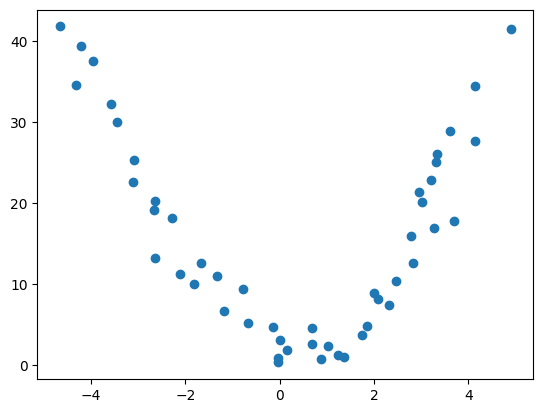

In [4]:
import matplotlib.pyplot as plt
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])

- Relation between X and y follow `U pattern`
- The data is `non-linear`.
- Since the points do not follow a straight-line pattern Linear Regression is not suitable.

In [5]:
x=df[['Temperature (°C)']]
y=df['Ice Cream Sales (units)']

### train_test_split( )

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
Xtrain,Xtest,Ytrain,Ytest=train_test_split(x,y,random_state=42,train_size=0.8)

### model training

In [7]:
model=LinearRegression()
model.fit(Xtrain,Ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### model evaluation

In [8]:
Ypred_train=model.predict(Xtrain)

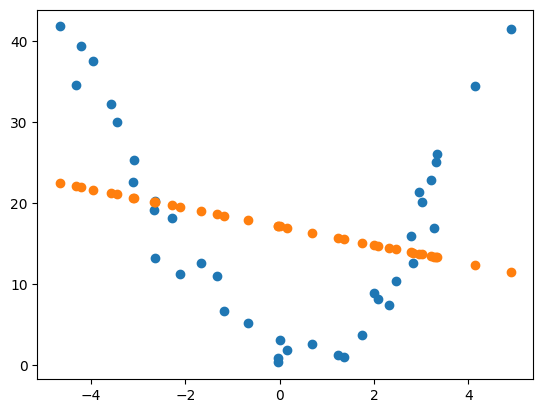

In [9]:
plt.scatter(Xtrain,Ytrain)
plt.scatter(Xtrain,Ypred_train)

- Model is not capturing the non-linear data pattern.

In [10]:
model.fit(Xtrain,Ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


- Model evaluation for seen data

In [11]:
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error
print("Train Score: ",r2_score(Ytrain,Ypred_train))


Train Score:  0.06579063815950037


In [12]:
print("MAE: ",mean_absolute_error(Ytrain,Ypred_train))

MAE:  10.136398159361041


In [13]:
print("RMSE: ", root_mean_squared_error(Ytrain,Ypred_train))

RMSE:  11.972117646423854


- The Linear Regression model performs poorly on the training data only 6.58% of the variance in the target variable

- model evaluation for unseen data

In [14]:
ypred_test=model.predict(Xtest)

In [15]:
print("Train Score: ",r2_score(Ytest,ypred_test))

Train Score:  -0.5751270190188227


In [16]:
print("MAE: ",mean_absolute_error(Ytest,ypred_test))

MAE:  11.752026695440602


In [17]:
print("RMSE: ",root_mean_squared_error(Ytest,ypred_test))

RMSE:  12.219913714640208


- The testing r2 score is negative, which means that the Linear Regression model performs worse.

### - Model is too simple not able to capture the patterns as Train and Test scores are very less so we can conclude that it is underfit

### - Here the solution is using the Polynomial Features

# Polynomial Features

In [18]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=6)
updated_Xtrain=poly.fit_transform(Xtrain)
updated_Xtest=poly.transform(Xtest)

In [19]:
updated_Xtrain

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00,
        -9.41892528e+00,  1.98915428e+01, -4.20083464e+01,
         8.87161534e+01],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01,
        -4.58271260e+01,  1.63994832e+02, -5.86864316e+02,
         2.10012548e+03],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00,
         1.24644343e+01,  2.88999281e+01,  6.70071202e+01,
         1.55362122e+02],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00,
        -1.90868405e+01,  5.10088335e+01, -1.36319109e+02,
         3.64307480e+02],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01,
        -6.16140128e+01,  2.43354469e+02, -9.61167676e+02,
         3.79628657e+03],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00,
        -3.00349918e+01,  9.33619735e+01, -2.90210104e+02,
         9.02100731e+02],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01,
         3.31184096e+01,  1.06355339e+02,  3.41545936e+02,
         1.0968290

In [20]:
model = LinearRegression()
model.fit(updated_Xtrain,Ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


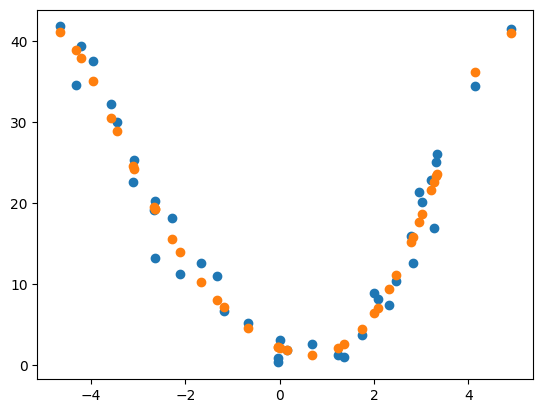

In [21]:
ypred_train=model.predict(updated_Xtrain)
plt.scatter(updated_Xtrain[:,1],Ytrain)
plt.scatter(updated_Xtrain[:,1],ypred_train)

In [22]:
print("Train Score: ",r2_score(Ytrain,ypred_train))
print("MAE: ",mean_absolute_error(Ytrain,ypred_train))
print("RMSE: ", root_mean_squared_error(Ytrain,ypred_train))

Train Score:  0.9668204963106728
MAE:  1.8312072004617517
RMSE:  2.2562322936388544


In [23]:
ypred_test=model.predict(updated_Xtest)
print("Test Score: ",r2_score(Ytest,ypred_test))
print("MAE: ",mean_absolute_error(Ytest,ypred_test))
print("RMSE: ", root_mean_squared_error(Ytest,ypred_test))

Test Score:  0.7313950333963021
MAE:  3.4214786739709853
RMSE:  5.046233798276592


- degree=2
  - Train Score:  0.9413665676490518
  - MAE:  2.5993732834161136
  - RMSE:  2.99931118717202
  - Test Score:  0.843055137193884
  - MAE:  3.2299819836597274
  - RMSE:  3.857304297171988

- degree=3
  - Train Score:  0.9469116778215552
  - MAE:  2.43566416014849
  - RMSE:  2.8539631962901724
  - Test Score:  0.8405107685716915
  - MAE:  3.228121129776889
  - RMSE:  3.888445634341502

- degree=4
  - Train Score:  0.9590068634754769
  - MAE:  2.0963498651499717
  - RMSE:  2.507866665138919
  - Test Score:  0.8054468908427623
  - MAE:  3.43761854085144
  - RMSE:  4.29466642062525

- degree=5
  - Train Score:  0.9625276778765787
  - MAE:  1.9547309669718669
  - RMSE:  2.3977515018639433
  - Test Score:  0.7781622233034887
  - MAE:  3.5107931284659424
  - RMSE:  4.585937173892854
- degree=6
  - Train Score:  0.9668204963106728
  - MAE:  1.8312072004617517
  - RMSE:  2.2562322936388544
  - Test Score:  0.7313950333963021
  - MAE:  3.4214786739709853
  - RMSE:  5.046233798276592

### Linear Regression was underfitting because it could not capture the non-linear pattern. After applying Polynomial Regression (degree 6), the training R² increased to 96.68% and testing R² to 73.14%. The model shows overall a good fit for the dataset.